In [ ]:
# Загрузка подготовленного датасета orbits.csv, полученного в первой практической работе
import pandas as pd
df = pd.read_csv("orbits.csv")
df.head()


,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,BSTAR,SEMIMAJOR_AXIS,...,SITE_TNSTA,SITE_TSC,SITE_TTMTR,SITE_VOSTO,SITE_WLPIS,SITE_WRAS,SITE_WSC,SITE_XSC,SITE_YSLA,SITE_YUN
0,2021-10-31 22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,26741,0.024341,20668.618,...,0,0,0,0,0,0,0,0,0,0
1,2021-10-31 16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,26743,0.000066,7358.038,...,0,0,0,0,0,0,0,0,0,0
2,2021-11-01 05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,26745,0.000000,41197.852,...,0,0,0,0,0,0,0,0,0,0
3,2021-10-31 11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,26754,0.000316,7015.076,...,0,1,0,0,0,0,0,0,0,0
4,2021-10-31 17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,26755,0.000408,7031.400,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Определение набора признаков и целевой переменной.
# Признаки — ключевые орбитальные параметры, цель — орбитальный период (PERIOD)
features = ['SEMIMAJOR_AXIS', 'APOAPSIS', 'PERIAPSIS', 'MEAN_MOTION', 'INCLINATION']
target = 'PERIOD'

X = df[features]
y = df[target]


In [ ]:
# Разбиение датасета на обучающую (80%) и тестовую (20%) выборки.
# random_state=42 фиксирует разбиение для воспроизводимости результатов
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((11489, 5), (2873, 5))

In [ ]:
# Базовая модель: Линейная регрессия.
# Обучение и оценка качества на тестовой выборке:
# MAE — средняя абсолютная ошибка, RMSE — среднеквадратичная ошибка, R² — коэффициент детерминации
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


Linear Regression:
MAE: 5.512588050261771
RMSE: 10.530257258228666
R²: 0.998898079871437


In [ ]:
# Модель 2: Случайный лес (Random Forest).
# Ансамблевый метод на основе множества деревьев решений — как правило лучше линейной регрессии
# на нелинейных зависимостях
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))


Random Forest:
MAE: 0.12252520710060934
RMSE: 2.247981689055403
R²: 0.9999497821988746


In [ ]:
# Модель 3: Градиентный бустинг (Gradient Boosting).
# Ансамблевый метод, где каждое следующее дерево исправляет ошибки предыдущего
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)

print("Gradient Boosting:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R²:", r2_score(y_test, y_pred_gb))


Gradient Boosting:
MAE: 0.32700717832328496
RMSE: 1.449375558227845
R²: 0.9999791246377648


In [ ]:
# Сводная таблица метрик всех трёх базовых моделей для удобного сравнения
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    ],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
    ]
}

pd.DataFrame(results)


,Model,MAE,RMSE,R²
0,Linear Regression,5.512588,10.530257,0.998898
1,Random Forest,0.122525,2.247982,0.999950
2,Gradient Boosting,0.327007,1.449376,0.999979


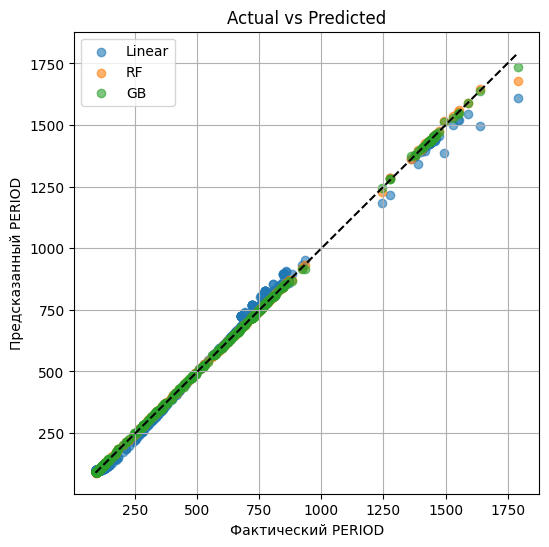

In [ ]:
# График Actual vs Predicted для всех трёх моделей.
# Идеальная модель — точки лежат на диагональной пунктирной линии
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, label="Linear", alpha=0.6)
plt.scatter(y_test, y_pred_rf, label="RF", alpha=0.6)
plt.scatter(y_test, y_pred_gb, label="GB", alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')

plt.xlabel("Фактический PERIOD")
plt.ylabel("Предсказанный PERIOD")
plt.legend()
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()


In [ ]:
# Подбор гиперпараметров для Random Forest и Gradient Boosting
# с помощью RandomizedSearchCV — перебирает случайные комбинации параметров
# и выбирает лучшую по кросс-валидации
from sklearn.model_selection import RandomizedSearchCV

# Параметры (умеренно большой поиск)
rf_param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 6, 10, 15],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["auto", "sqrt"]
}

gb_param_dist = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2,3,4],
    "subsample": [0.6, 0.8, 1.0]
}

# RF
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist, n_iter=12, cv=3, scoring="neg_mean_squared_error",
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print("RF best params:", rf_search.best_params_)

# GB
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_dist, n_iter=12, cv=3, scoring="neg_mean_squared_error",
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print("GB best params:", gb_search.best_params_)

# Сохраняем лучшие модели в переменные
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RF best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GB best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
# Вспомогательная функция для оценки модели на train и test выборках.
# Считаем метрики отдельно для обеих выборок, чтобы диагностировать переобучение
def eval_and_print(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    tr = {"mae": mean_absolute_error(y_tr, y_tr_pred),
          "rmse": np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
          "r2": r2_score(y_tr, y_tr_pred)}
    te = {"mae": mean_absolute_error(y_te, y_te_pred),
          "rmse": np.sqrt(mean_squared_error(y_te, y_te_pred)),
          "r2": r2_score(y_te, y_te_pred)}
    print(f"\n{name} — train: MAE={tr['mae']:.3f}, RMSE={tr['rmse']:.3f}, R2={tr['r2']:.4f}")
    print(f"{name} — test : MAE={te['mae']:.3f}, RMSE={te['rmse']:.3f}, R2={te['r2']:.4f}")
    return {"name": name, "train": tr, "test": te, "y_test_pred": y_te_pred}

res_lr = eval_and_print("Linear (baseline)", model_lr, X_train, X_test, y_train, y_test)
res_rf_base = eval_and_print("RF (base)", model_rf, X_train, X_test, y_train, y_test)
res_gb_base = eval_and_print("GB (base)", model_gb, X_train, X_test, y_train, y_test)
res_rf_tuned = eval_and_print("RF (tuned)", best_rf, X_train, X_test, y_train, y_test)
res_gb_tuned = eval_and_print("GB (tuned)", best_gb, X_train, X_test, y_train, y_test)



Linear (baseline) — train: MAE=5.337, RMSE=9.344, R2=0.9991
Linear (baseline) — test : MAE=5.513, RMSE=10.530, R2=0.9989

RF (base) — train: MAE=0.038, RMSE=0.519, R2=1.0000
RF (base) — test : MAE=0.123, RMSE=2.248, R2=0.9999

GB (base) — train: MAE=0.282, RMSE=0.746, R2=1.0000
GB (base) — test : MAE=0.327, RMSE=1.449, R2=1.0000

RF (tuned) — train: MAE=0.135, RMSE=1.247, R2=1.0000
RF (tuned) — test : MAE=0.275, RMSE=4.169, R2=0.9998

GB (tuned) — train: MAE=0.086, RMSE=0.195, R2=1.0000
GB (tuned) — test : MAE=0.175, RMSE=1.579, R2=1.0000


In [ ]:
# Итоговая сравнительная таблица: базовые vs. оптимизированные модели
# на обучающей и тестовой выборках
rows = []
for r in [res_lr, res_rf_base, res_rf_tuned, res_gb_base, res_gb_tuned]:
    rows.append({
        "model": r["name"],
        "mae_train": r["train"]["mae"],
        "rmse_train": r["train"]["rmse"],
        "r2_train": r["train"]["r2"],
        "mae_test": r["test"]["mae"],
        "rmse_test": r["test"]["rmse"],
        "r2_test": r["test"]["r2"],
    })
comp_df = pd.DataFrame(rows).sort_values("r2_test", ascending=False).reset_index(drop=True)
display(comp_df)
comp_df.to_csv("models_comparison.csv", index=False)
print("Saved models_comparison.csv")


,model,mae_train,rmse_train,r2_train,mae_test,rmse_test,r2_test
0,GB (base),0.282491,0.746097,0.999994,0.327007,1.449376,0.999979
1,GB (tuned),0.085611,0.195143,1.000000,0.175005,1.579286,0.999975
2,RF (base),0.038011,0.518609,0.999997,0.122525,2.247982,0.999950
3,RF (tuned),0.135389,1.246762,0.999985,0.275423,4.168998,0.999827
4,Linear (baseline),5.336733,9.343666,0.999133,5.512588,10.530257,0.998898


Saved models_comparison.csv


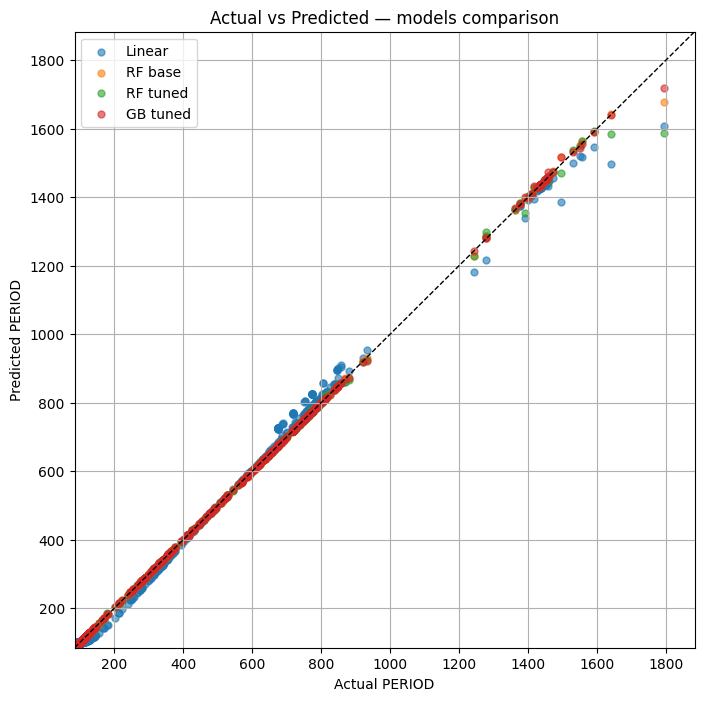

In [ ]:
# Обновлённый график Actual vs Predicted: базовые и оптимизированные модели вместе.
# Чем ближе точки к диагонали — тем точнее модель
plt.figure(figsize=(8,8))
pad_low, pad_high = y_test.min()*0.95, y_test.max()*1.05

plt.scatter(y_test, res_lr["y_test_pred"], s=25, alpha=0.6, label="Linear")
plt.scatter(y_test, res_rf_base["y_test_pred"], s=25, alpha=0.6, label="RF base")
plt.scatter(y_test, res_rf_tuned["y_test_pred"], s=25, alpha=0.6, label="RF tuned")
plt.scatter(y_test, res_gb_tuned["y_test_pred"], s=25, alpha=0.6, label="GB tuned")

plt.plot([pad_low, pad_high], [pad_low, pad_high], "k--", linewidth=1)
plt.xlim(pad_low, pad_high)
plt.ylim(pad_low, pad_high)
plt.xlabel("Actual PERIOD")
plt.ylabel("Predicted PERIOD")
plt.title("Actual vs Predicted — models comparison")
plt.legend()
plt.grid(True)
plt.show()


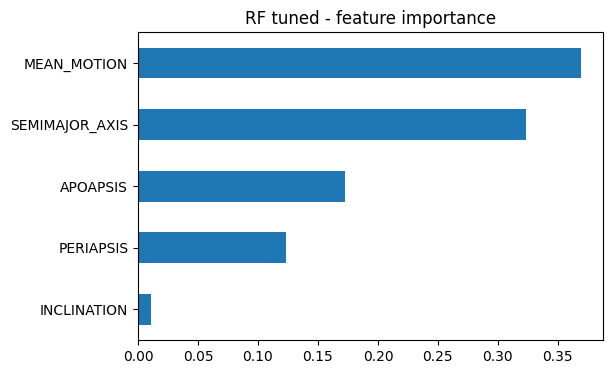

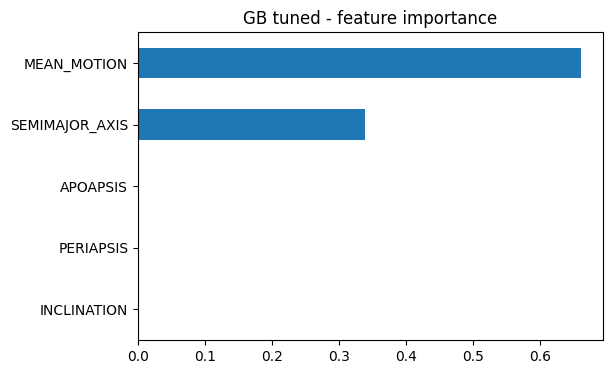

In [ ]:
# Важность признаков (Feature Importance) для Random Forest и Gradient Boosting.
# Показывает, какие орбитальные параметры сильнее всего влияют на предсказание периода
def plot_fi(model, feat_names, title):
    if hasattr(model, "feature_importances_"):
        fi = pd.Series(model.feature_importances_, index=feat_names).sort_values()
        plt.figure(figsize=(6,4))
        fi.plot(kind="barh")
        plt.title(title)
        plt.show()
    else:
        print("Model has no feature_importances_")

plot_fi(best_rf, features, "RF tuned - feature importance")
plot_fi(best_gb, features, "GB tuned - feature importance")


In [ ]:
# Эксперименты с различными условиями обучения:
# A) разбиение 70/30 вместо 80/20
# B) нормализация признаков (StandardScaler) перед обучением
# Цель — проверить устойчивость моделей к изменению условий
from sklearn.preprocessing import StandardScaler

exp_results = []

# Эксперимент A: split 70/30
X_trA, X_teA, y_trA, y_teA = train_test_split(X, y, test_size=0.3, random_state=42)
# scale for LR
sc_A = StandardScaler().fit(X_trA)
lrA = LinearRegression().fit(sc_A.transform(X_trA), y_trA)
rfA = RandomForestRegressor(**best_rf.get_params()).fit(X_trA, y_trA)
exp_results.append({
    "desc": "split70_30",
    "LR_rmse_test": np.sqrt(mean_squared_error(y_teA, lrA.predict(sc_A.transform(X_teA)))),
    "RF_rmse_test": np.sqrt(mean_squared_error(y_teA, rfA.predict(X_teA)))
})

# Эксперимент B: drop APOAPSIS
X_drop = X.drop(columns=["APOAPSIS"])
X_trB, X_teB, y_trB, y_teB = train_test_split(X_drop, y, test_size=0.2, random_state=42)
sc_B = StandardScaler().fit(X_trB)
lrB = LinearRegression().fit(sc_B.transform(X_trB), y_trB)
rfB = RandomForestRegressor(**best_rf.get_params()).fit(X_trB, y_trB)
exp_results.append({
    "desc": "drop_APOAPSIS",
    "LR_rmse_test": np.sqrt(mean_squared_error(y_teB, lrB.predict(sc_B.transform(X_teB)))),
    "RF_rmse_test": np.sqrt(mean_squared_error(y_teB, rfB.predict(X_teB)))
})

# Эксперимент C: half dataset (50%)
df_small = df.sample(frac=0.5, random_state=42)
X_s = df_small[features]; y_s = df_small[target]
X_trC, X_teC, y_trC, y_teC = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
sc_C = StandardScaler().fit(X_trC)
lrC = LinearRegression().fit(sc_C.transform(X_trC), y_trC)
rfC = RandomForestRegressor(**best_rf.get_params()).fit(X_trC, y_trC)
exp_results.append({
    "desc": "half_dataset",
    "LR_rmse_test": np.sqrt(mean_squared_error(y_teC, lrC.predict(sc_C.transform(X_teC)))),
    "RF_rmse_test": np.sqrt(mean_squared_error(y_teC, rfC.predict(X_teC)))
})

exp_df = pd.DataFrame(exp_results)
display(exp_df)
exp_df.to_csv("experiments_summary.csv", index=False)
print("Saved experiments_summary.csv")


,desc,LR_rmse_test,RF_rmse_test
0,split70_30,10.432183,4.810423
1,drop_APOAPSIS,10.530242,4.237566
2,half_dataset,9.971449,3.636548


Saved experiments_summary.csv


In [ ]:
# Сохранение обученных моделей на диск с помощью joblib.
# Позволяет загрузить модели позже без повторного обучения
import joblib
joblib.dump(best_rf, "best_rf.joblib")
joblib.dump(best_gb, "best_gb.joblib")
joblib.dump(model_lr, "linear_baseline.joblib")
print("Saved models in ")


Saved models in 


In [ ]:
# Кросс-валидация (5-fold) для объективной оценки качества моделей.
# В отличие от одного разбиения, CV даёт более надёжную оценку обобщающей способности
from sklearn.model_selection import cross_val_score

# Linear Regression (со скейлингом)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

cv_lr = cross_val_score(
    pipe_lr, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

# Random Forest (tuned)
cv_rf = cross_val_score(
    best_rf, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

# Gradient Boosting (tuned)
cv_gb = cross_val_score(
    best_gb, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("CV RMSE (Linear):", -cv_lr.mean())
print("CV RMSE (RF tuned):", -cv_rf.mean())
print("CV RMSE (GB tuned):", -cv_gb.mean())


CV RMSE (Linear): 9.809362527729542
CV RMSE (RF tuned): 3.199146790175512
CV RMSE (GB tuned): 0.9601444887984651


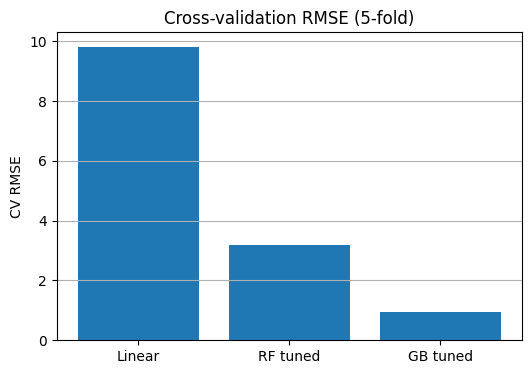

In [ ]:
# Визуализация результатов кросс-валидации: сравнение CV RMSE по всем моделям
models = ["Linear", "RF tuned", "GB tuned"]
cv_means = [-cv_lr.mean(), -cv_rf.mean(), -cv_gb.mean()]

plt.figure(figsize=(6,4))
plt.bar(models, cv_means)
plt.ylabel("CV RMSE")
plt.title("Cross-validation RMSE (5-fold)")
plt.grid(axis="y")
plt.show()


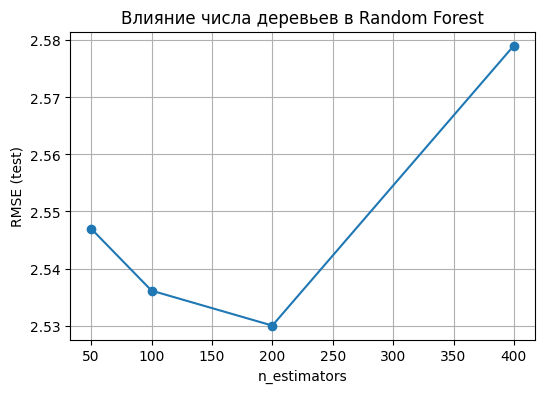

In [ ]:
# Исследование влияния числа деревьев (n_estimators) на качество Random Forest.
# Помогает найти баланс между точностью и временем обучения
from sklearn.metrics import mean_squared_error

n_estimators_list = [50, 100, 200, 400]
rmse_list = []

for n in n_estimators_list:
    rf_tmp = RandomForestRegressor(
        n_estimators=n,
        max_depth=best_rf.max_depth,
        min_samples_split=best_rf.min_samples_split,
        min_samples_leaf=best_rf.min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    rf_tmp.fit(X_train, y_train)
    y_pred_tmp = rf_tmp.predict(X_test)
    rmse_tmp = np.sqrt(mean_squared_error(y_test, y_pred_tmp))
    rmse_list.append(rmse_tmp)

plt.figure(figsize=(6,4))
plt.plot(n_estimators_list, rmse_list, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("RMSE (test)")
plt.title("Влияние числа деревьев в Random Forest")
plt.grid(True)
plt.show()


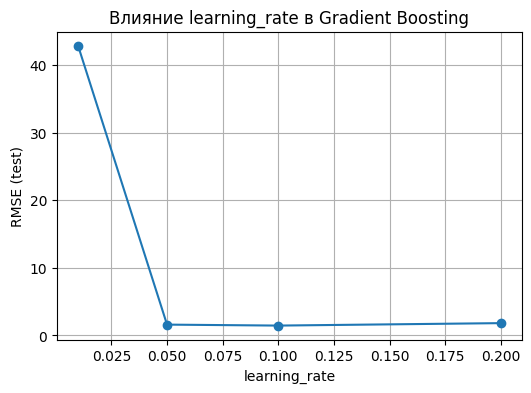

In [ ]:
# Исследование влияния скорости обучения (learning_rate) на качество Gradient Boosting.
# Маленький learning_rate требует больше деревьев, но даёт более стабильный результат
learning_rates = [0.01, 0.05, 0.1, 0.2]
rmse_lr = []

for lr in learning_rates:
    gb_tmp = GradientBoostingRegressor(
        n_estimators=best_gb.n_estimators,
        learning_rate=lr,
        max_depth=best_gb.max_depth,
        subsample=best_gb.subsample,
        random_state=42
    )
    gb_tmp.fit(X_train, y_train)
    y_pred_tmp = gb_tmp.predict(X_test)
    rmse_tmp = np.sqrt(mean_squared_error(y_test, y_pred_tmp))
    rmse_lr.append(rmse_tmp)

plt.figure(figsize=(6,4))
plt.plot(learning_rates, rmse_lr, marker="o")
plt.xlabel("learning_rate")
plt.ylabel("RMSE (test)")
plt.title("Влияние learning_rate в Gradient Boosting")
plt.grid(True)
plt.show()
